<a href="https://colab.research.google.com/github/Prajjwal2123/internship-assignments/blob/main/week4_Prajjwal_sharma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

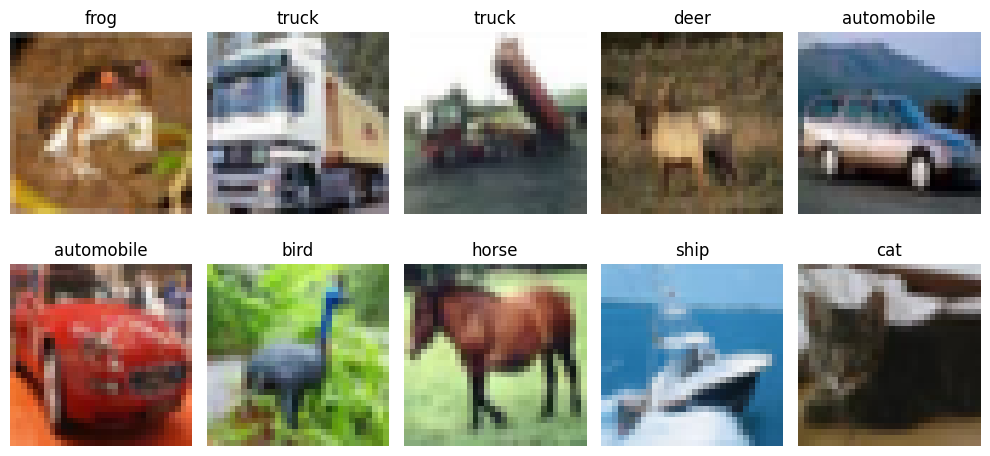

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.2676 - loss: 1.9932 - val_accuracy: 0.3366 - val_loss: 1.8658
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3085 - loss: 1.8825 - val_accuracy: 0.3594 - val_loss: 1.8115
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3346 - loss: 1.8215 - val_accuracy: 0.3702 - val_loss: 1.7865
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3490 - loss: 1.7819 - val_accuracy: 0.3766 - val_loss: 1.7407
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.3562 - loss: 1.7694 - val_accuracy: 0.3722 - val_loss: 1.7525
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step - accuracy: 0.3688 - loss: 1.7421 - val_accuracy: 0.3838 - val_loss: 1.7358
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.3684 - loss: 1.7349 - val_accuracy: 0.4046 - val_loss: 1.6739
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3761 - loss: 1.7143 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4107 - loss: 1.6822
ANN Test Accuracy: 0.4106999933719635


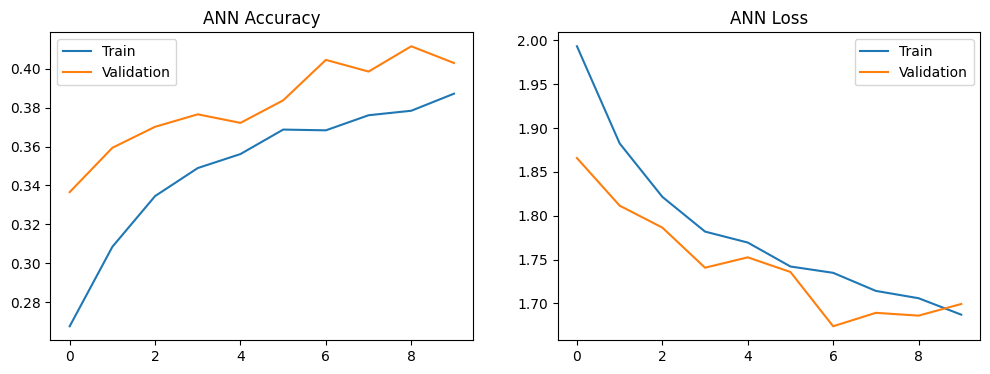

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(ann_history.history['accuracy'])
plt.plot(ann_history.history['val_accuracy'])
plt.title("ANN Accuracy")
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(ann_history.history['loss'])
plt.plot(ann_history.history['val_loss'])
plt.title("ANN Loss")
plt.legend(['Train','Validation'])

plt.show()

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 115ms/step - accuracy: 0.4613 - loss: 1.5004 - val_accuracy: 0.5606 - val_loss: 1.2223
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.6050 - loss: 1.1296 - val_accuracy: 0.5698 - val_loss: 1.2210
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 117ms/step - accuracy: 0.6653 - loss: 0.9616 - val_accuracy: 0.6816 - val_loss: 0.9104
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.7128 - loss: 0.8294 - val_accuracy: 0.6176 - val_loss: 1.1479
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 115ms/step - accuracy: 0.7434 - loss: 0.7384 - val_accuracy: 0.6894 - val_loss: 0.9336
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 117ms/step - accuracy: 0.7656 - loss: 0.6659 - val_accuracy: 0.7112 - val_loss: 0.8686
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.7895 - loss: 0.5967 - val_accuracy: 0.7032 - val_loss: 0.8815
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 116ms/step - accuracy: 0.8117 - loss: 

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7131 - loss: 1.0138
CNN Test Accuracy: 0.713100016117096


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


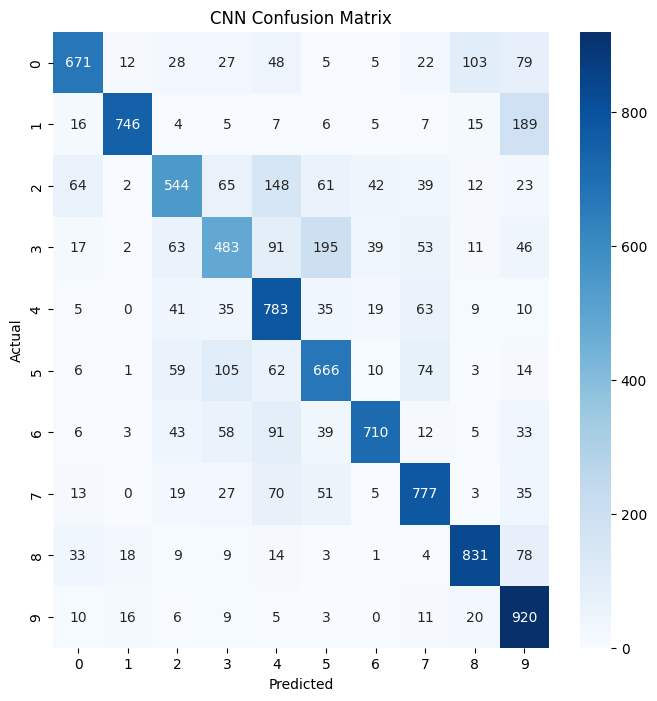

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = cnn_model.predict(x_test_norm)
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(
    y_test.flatten(),
    predicted_labels
)

plt.figure(figsize=(8,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

## 📈 Compare Learning Curves

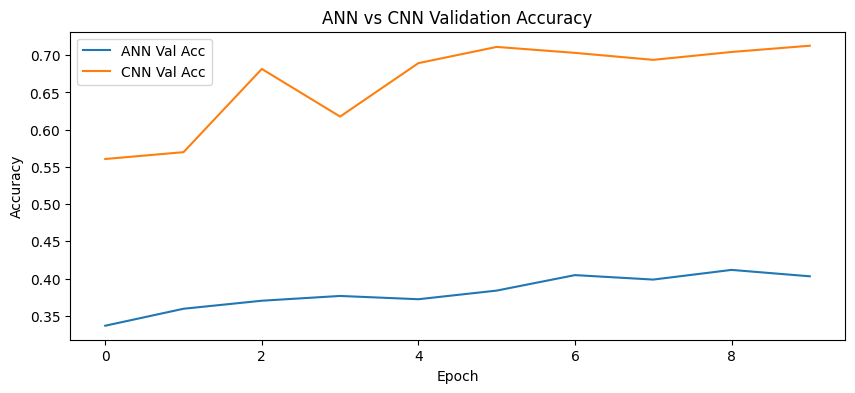

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, 3, activation='relu',
                  input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 91ms/step - accuracy: 0.3579 - loss: 1.7561 - val_accuracy: 0.4852 - val_loss: 1.4071
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 90ms/step - accuracy: 0.4569 - loss: 1.5100 - val_accuracy: 0.5020 - val_loss: 1.4012
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.4972 - loss: 1.4104 - val_accuracy: 0.5546 - val_loss: 1.2198
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 87ms/step - accuracy: 0.5209 - loss: 1.3476 - val_accuracy: 0.5546 - val_loss: 1.2218
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.5422 - loss: 1.2988 - val_accuracy: 0.6006 - val_loss: 1.1224
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.5536 - loss: 1.2657 - val_accuracy: 0.6066 - val_loss: 1.1695
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 88ms/step - accuracy: 0.5617 - loss: 1.2392 - val_accuracy: 0.6480 - val_loss: 1.0128
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 85ms/step - accuracy: 0.5745 - loss: 1.2133 - 

In [ ]:
comparison = pd.DataFrame({
    "Model":[
        "ANN",
        "CNN + BN + Dropout",
        "CNN + Augmentation"
    ],
    "Accuracy":[
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc
    ]
})

comparison

,Model,Accuracy
0,ANN,0.4107
1,CNN + BN + Dropout,0.7131
2,CNN + Augmentation,0.6398


# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [
        round(ann_test_acc*100,2),
        round(cnn_test_acc*100,2)
    ]
})
print(comparison)

  Model  Test Accuracy
0   ANN          41.07
1   CNN          71.31


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**